<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('airline_passengers.csv', parse_dates=['month'])
df.head()


,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df = df.set_index('month').asfreq('MS')
df.head()


,thousands_of_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


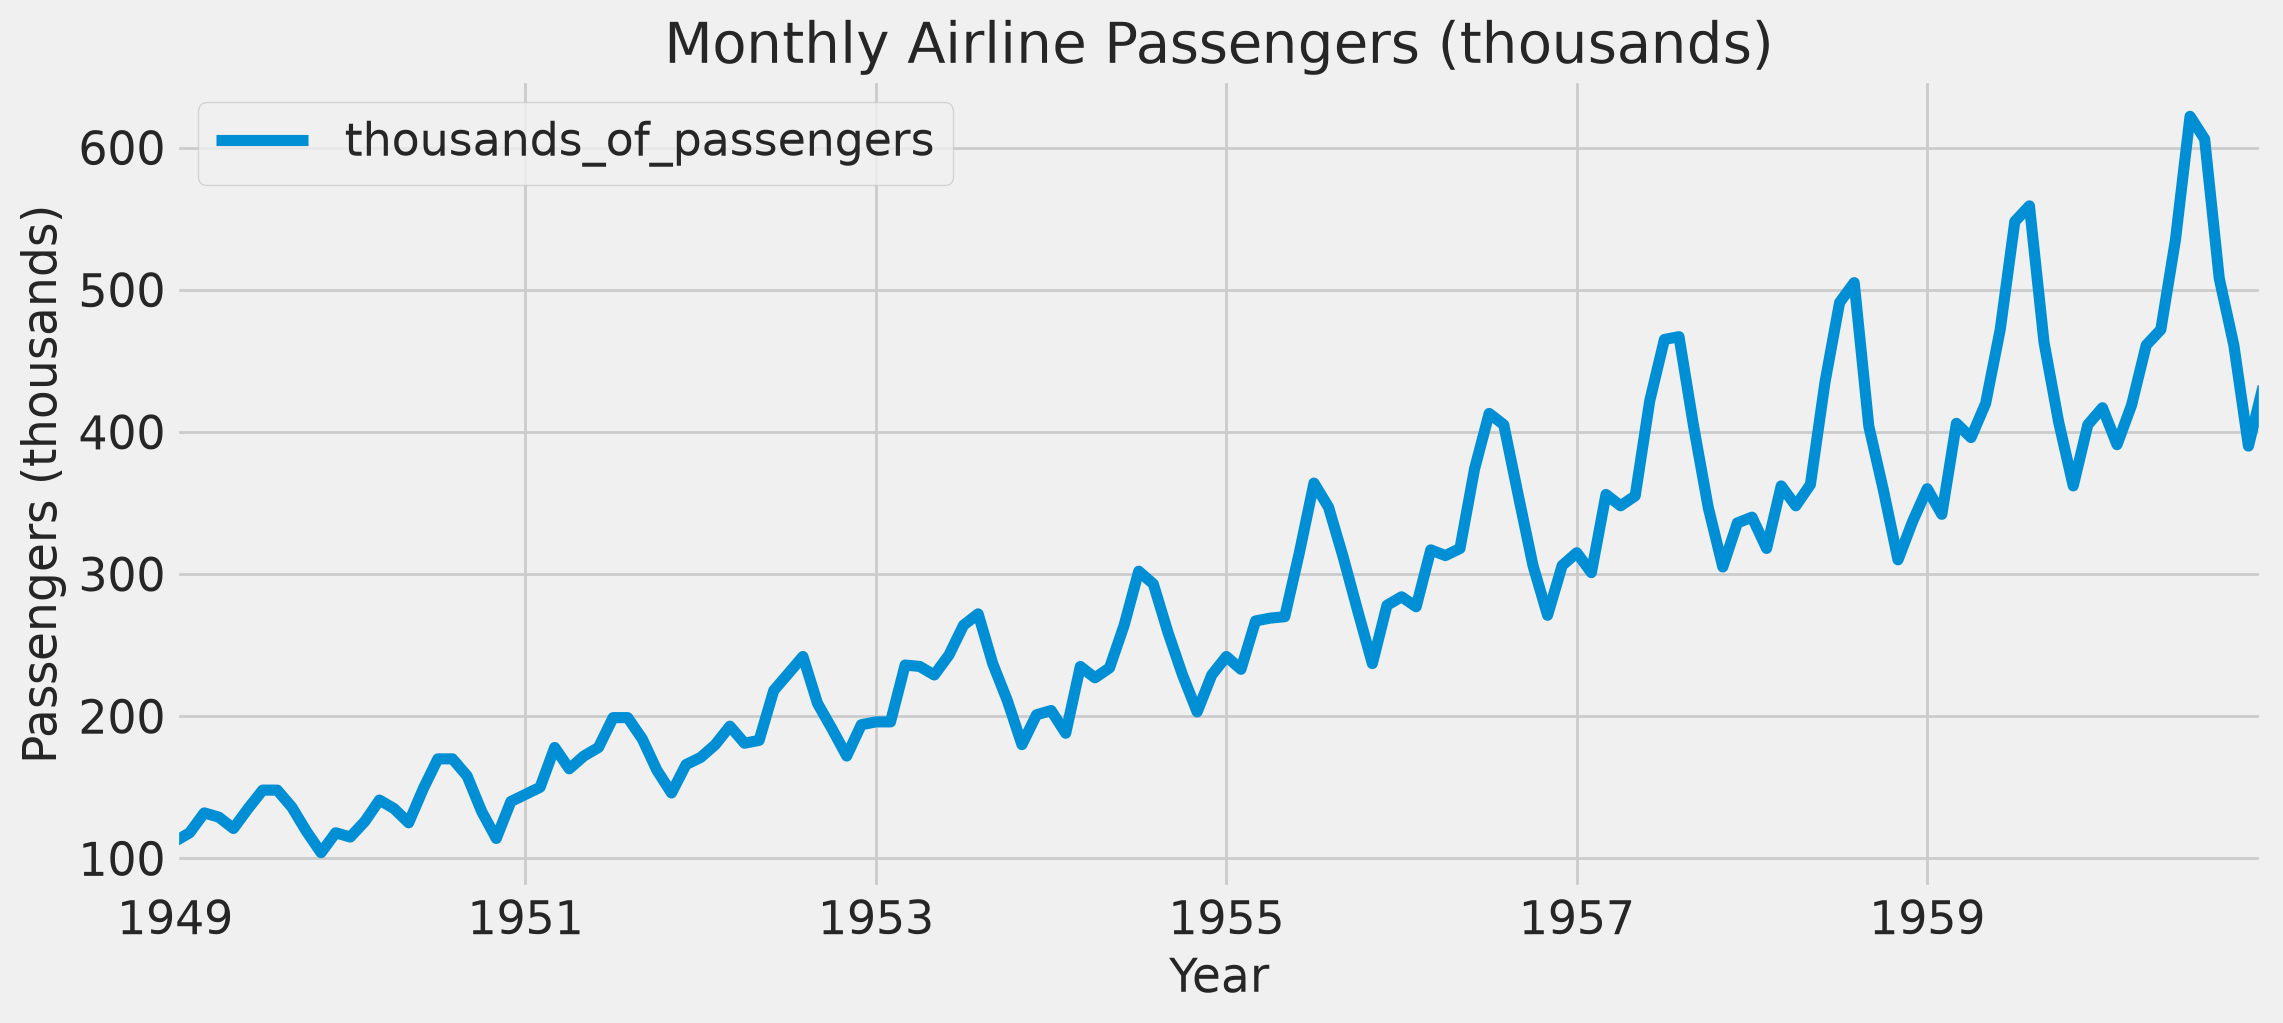

Shape: (144, 1)
       thousands_of_passengers
count               144.000000
mean                280.298611
std                 119.966317
min                 104.000000
25%                 180.000000
50%                 265.500000
75%                 360.500000
max                 622.000000


In [7]:
# 1c. Plot the full series and look at shape.
df.plot(figsize=(12, 5), title='Monthly Airline Passengers (thousands)')
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.show()
print(f"Shape: {df.shape}")
print(df.describe())


---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'], 'Original Series')


Augmented Dickey-Fuller Test: Original Series
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
df_diff1 = df['thousands_of_passengers'].diff().dropna()
adf_test(df_diff1, 'First Difference')


Augmented Dickey-Fuller Test: First Difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test
df_diff2 = df_diff1.diff().dropna()
adf_test(df_diff2, 'Second Difference')


Augmented Dickey-Fuller Test: Second Difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 1`

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

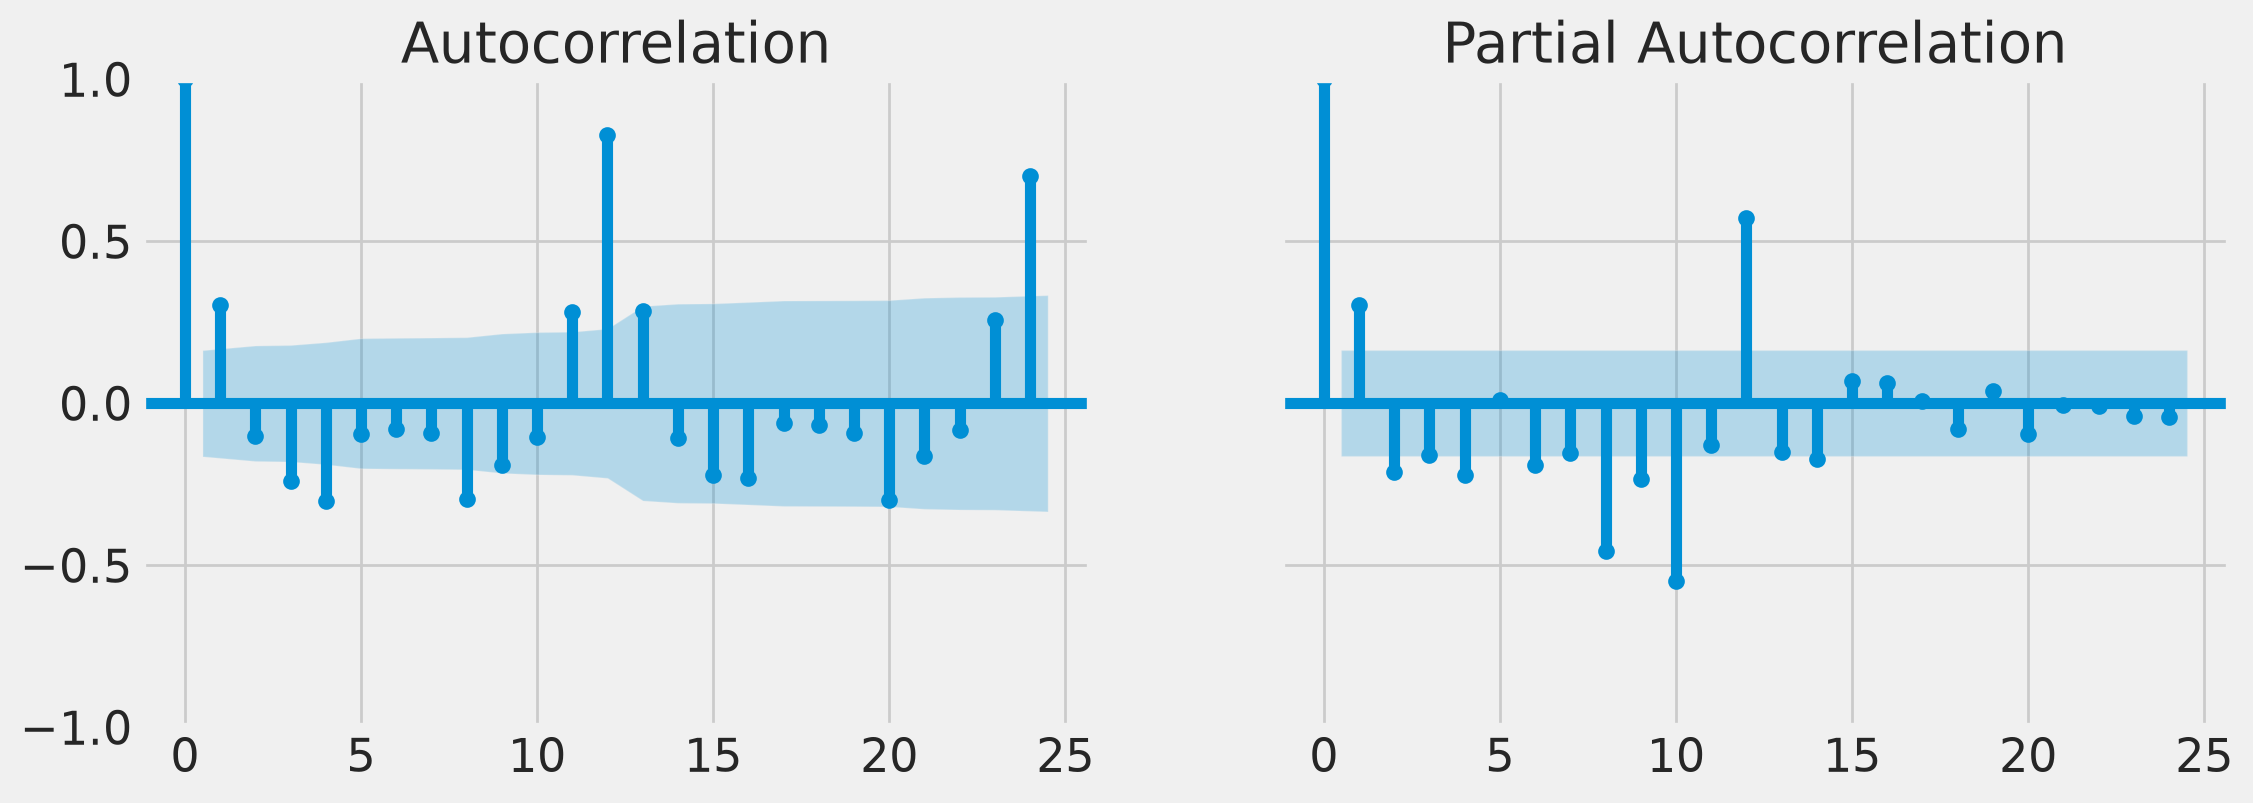

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df_diff1, lags=24)
plt.show()


**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 1 (PACF cuts off after lag 1)
- q (MA terms): 1 (ACF cuts off after lag 1)

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [12]:
# Run auto_arima with seasonal=False and print the summary
auto_arima_model = auto_arima(df['thousands_of_passengers'], seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)
print(auto_arima_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=10.97 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.65 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=1.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.89 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.52 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.11 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.92 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.40 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.87 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.21 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.59 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [13]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")


Train shape: (132, 1), Test shape: (12, 1)


### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [14]:
# Fit ARIMA(p,d,q) on the training set
order = auto_arima_model.order
print(f"ARIMA order: {order}")
arima_model = ARIMA(df_train['thousands_of_passengers'], order=order)
arima_fit = arima_model.fit()
print(arima_fit.summary())


ARIMA order: (4, 1, 3)


/home/ultori/jupyter-env/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/ultori/jupyter-env/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                  SARIMAX Results                                  
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(4, 1, 3)   Log Likelihood                -607.206
Date:                     Thu, 13 Aug 2026   AIC                           1230.412
Time:                             18:36:08   BIC                           1253.414
Sample:                         01-01-1949   HQIC                          1239.759
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5693      0.115     -4.968      0.000      -0.794      -0.345
ar.L2          0.4828      0.123      3.935      0.000       0.242       0.723
ar.L3       

### A7. Predict on the test set

In [15]:
# Predict over the test period
arima_pred = arima_fit.forecast(steps=12)
arima_pred.index = df_test.index
arima_pred


month
1960-01-01    441.014226
1960-02-01    446.034149
1960-03-01    469.988824
1960-04-01    440.043189
1960-05-01    450.040043
1960-06-01    430.002111
1960-07-01    429.978879
1960-08-01    437.445809
1960-09-01    425.521789
1960-10-01    446.595405
1960-11-01    429.723124
1960-12-01    444.134238
Freq: MS, Name: predicted_mean, dtype: float64

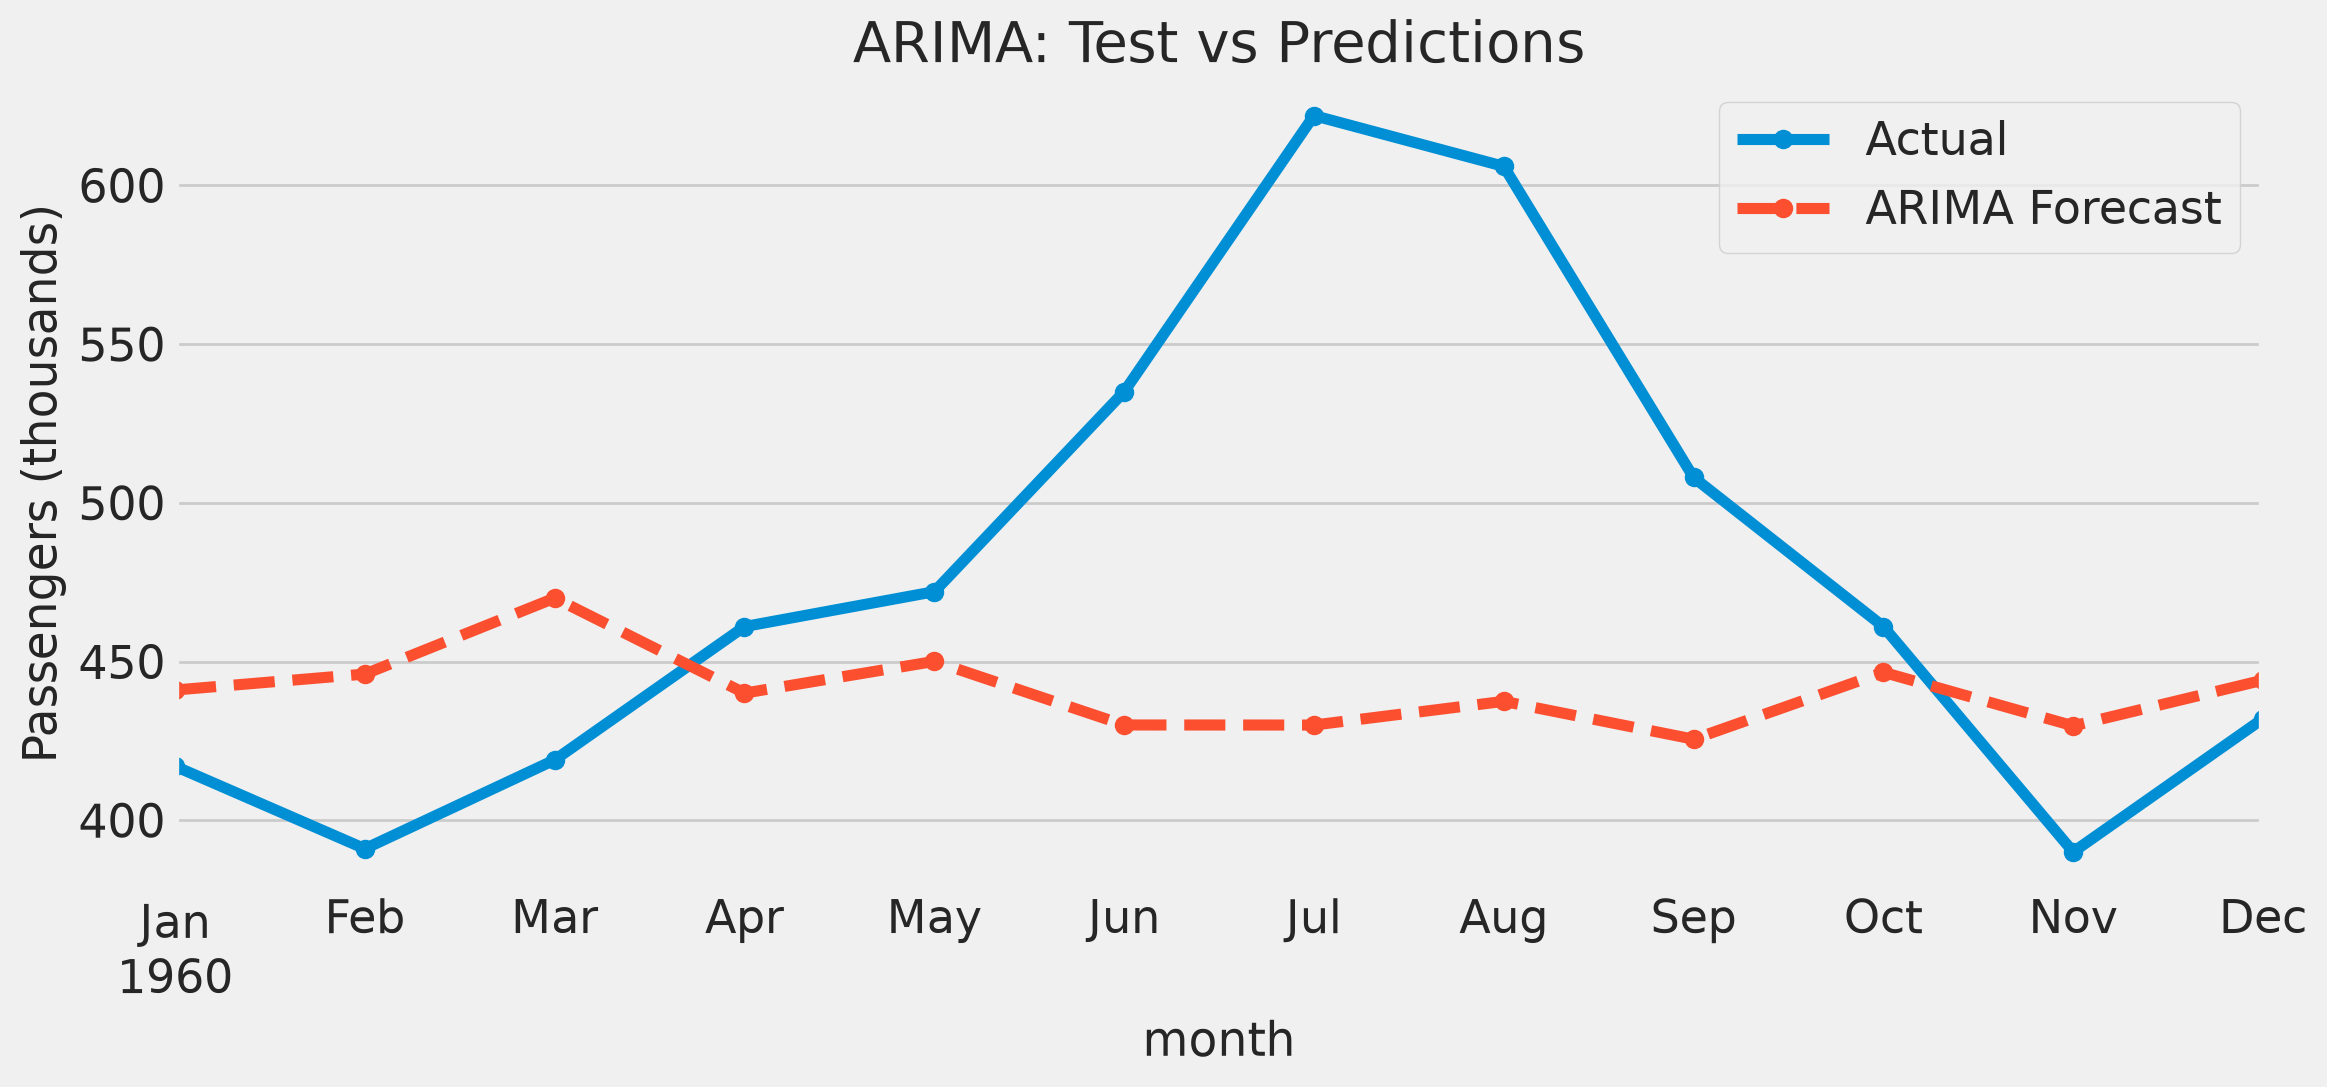

In [16]:
# Plot the test data vs predictions
fig, ax = plt.subplots(figsize=(12, 5))
df_test['thousands_of_passengers'].plot(ax=ax, label='Actual', marker='o')
arima_pred.plot(ax=ax, label='ARIMA Forecast', marker='o', linestyle='--')
ax.set_title('ARIMA: Test vs Predictions')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.show()


### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [17]:
# Compute RMSE
arima_rmse = rmse(df_test['thousands_of_passengers'], arima_pred)
print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"Test mean: {df_test['thousands_of_passengers'].mean():.2f}")
print(f"RMSE as % of mean: {arima_rmse / df_test['thousands_of_passengers'].mean() * 100:.1f}%")


ARIMA RMSE: 87.64
Test mean: 476.17
RMSE as % of mean: 18.4%


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

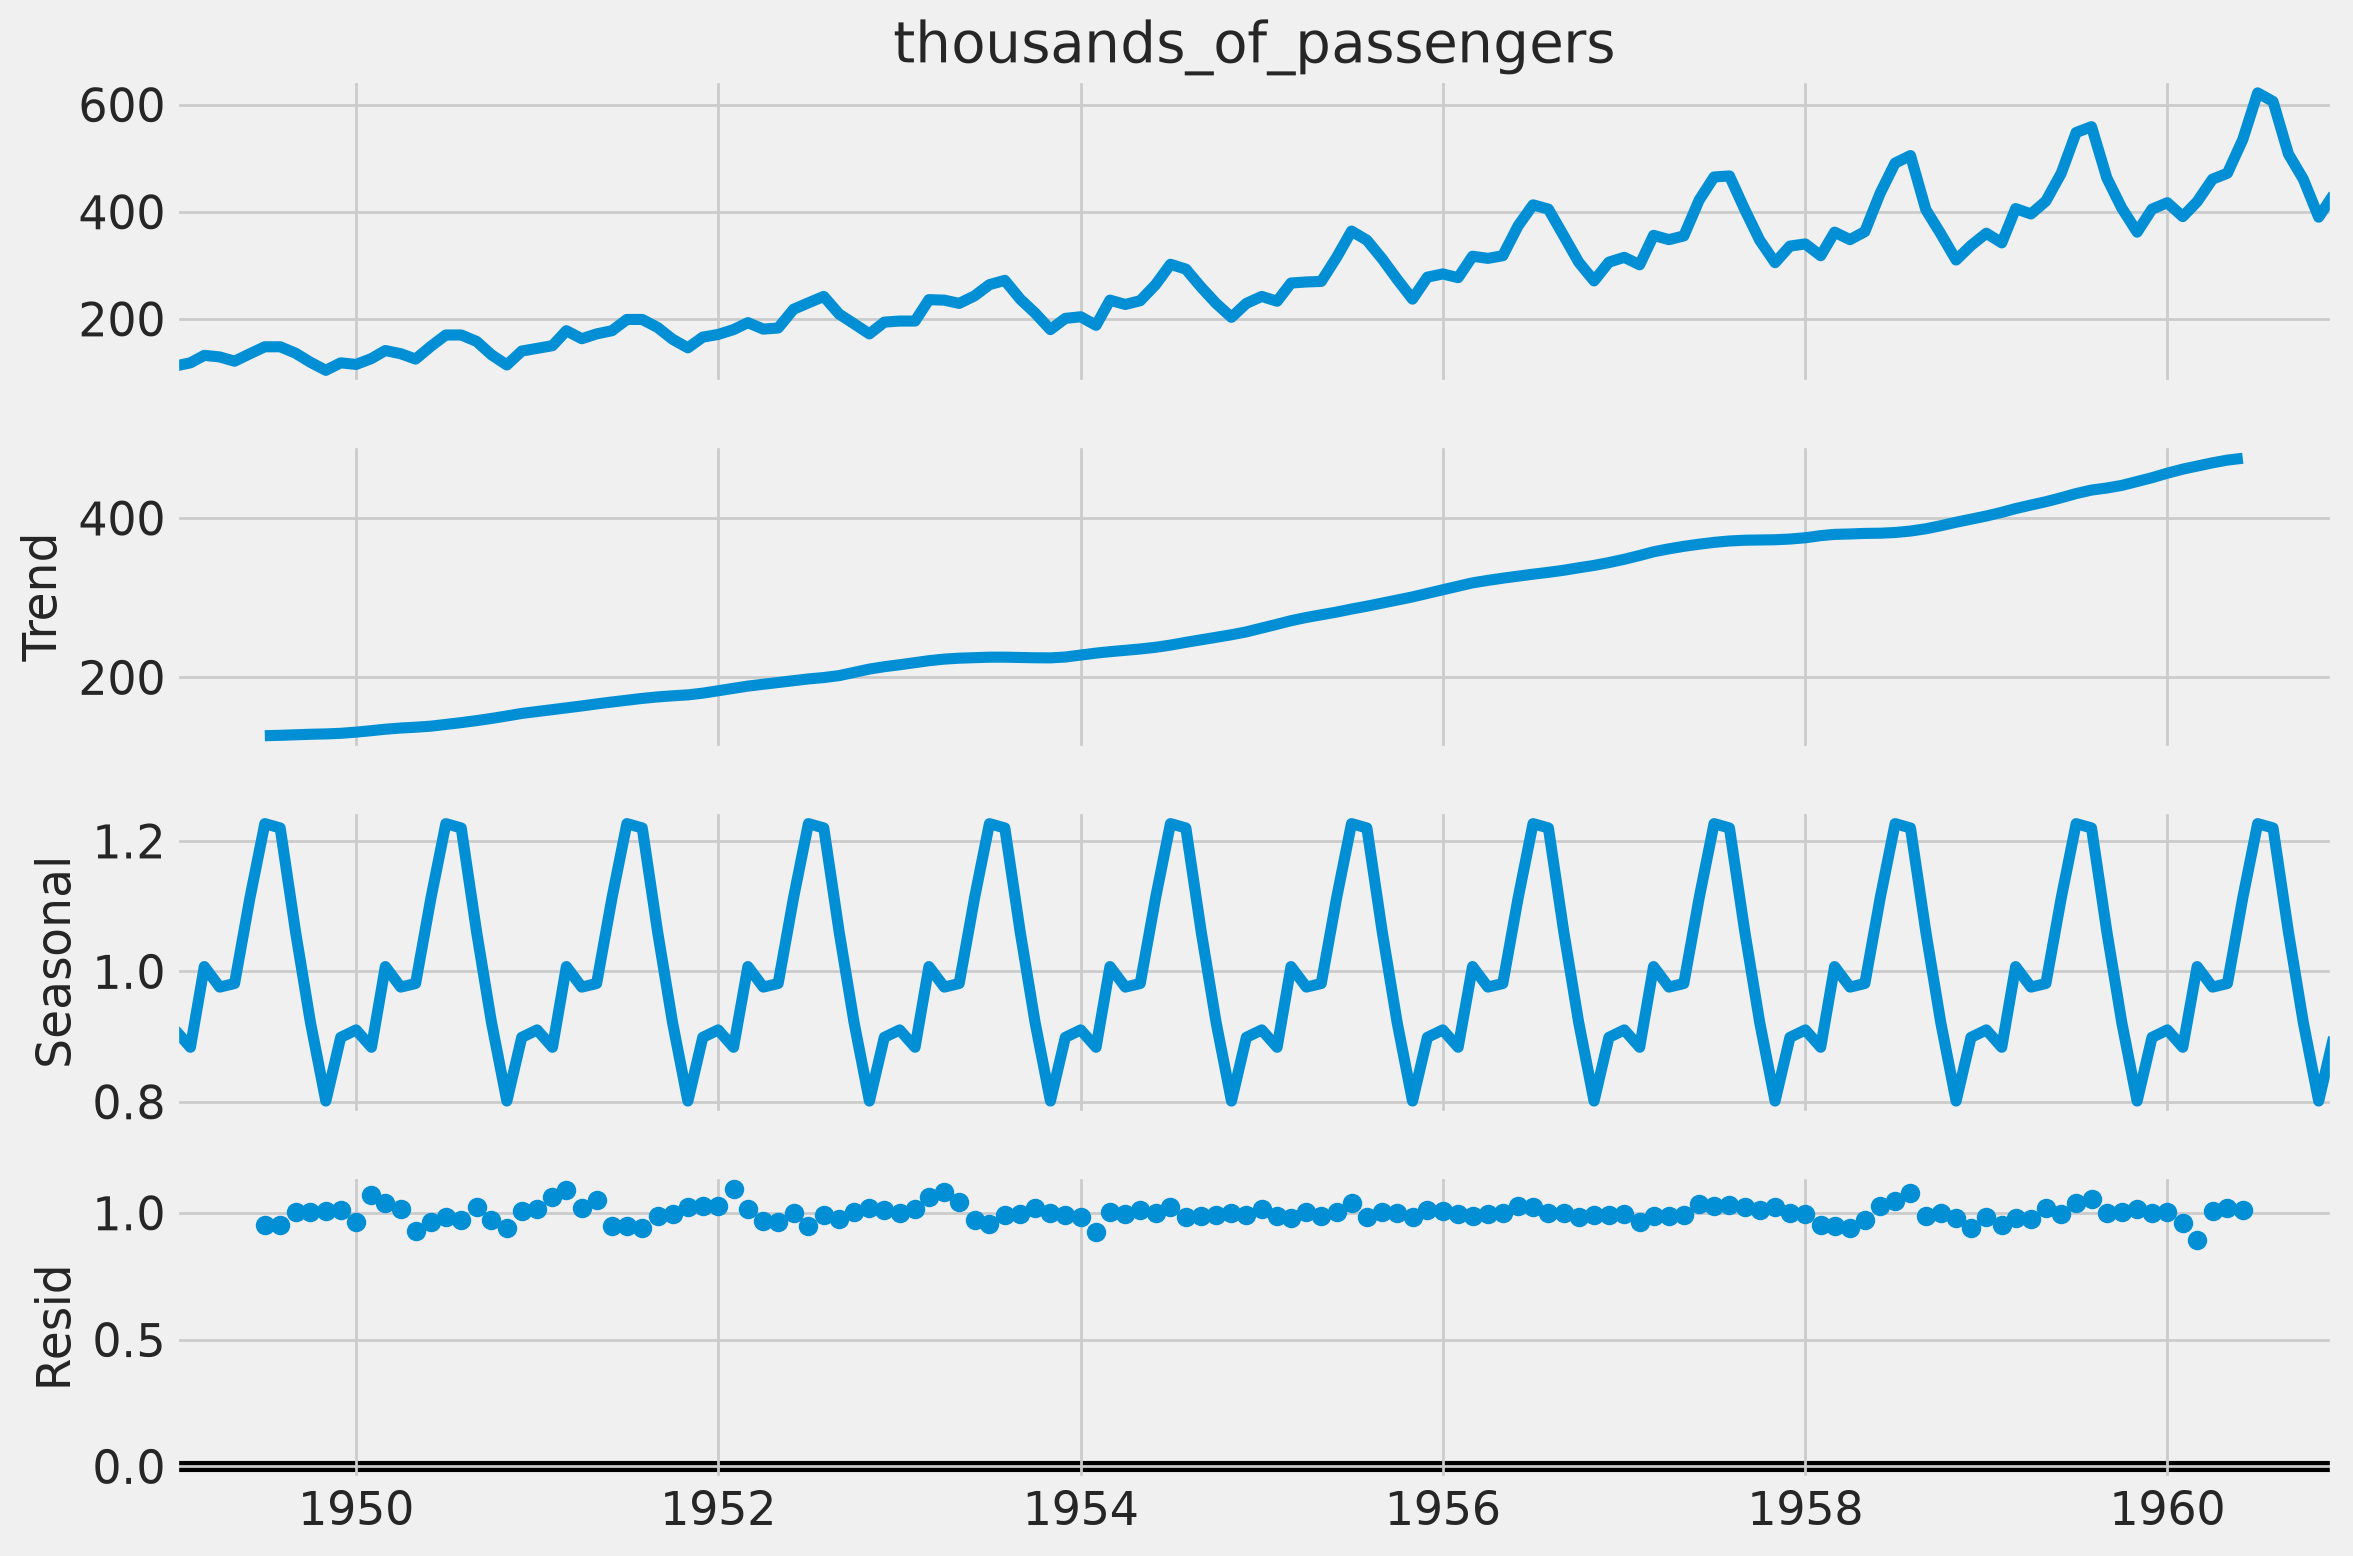

In [18]:
#YOUR CODE HERE
decomposition = seasonal_decompose(df['thousands_of_passengers'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

**Answer:** Yes, there's a clear repeating seasonal pattern with a period of 12 months (peaks in summer months July-August, troughs in winter months November-February).

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [19]:
#YOUR CODE HERE
sarima_auto = auto_arima(df_train['thousands_of_passengers'], seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True)
print(sarima_auto.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=16.68 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1022.234, Time=0.13 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=906.857, Time=3.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=963.555, Time=3.87 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1192.711, Time=0.12 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=907.180, Time=0.72 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=908.543, Time=9.12 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=7.90 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=907.120, Time=3.87 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=17.42 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1021.611, Time=2.71 sec
 ARIMA(2,0,0)(1,1,0)[12] intercept   : AIC=906.396, Time=2.61 sec
 ARIMA(2,0,0)(0,1,0)[12] intercept   : AIC=906.075, Time=0.47 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=906.713, Time=1.73 sec
 ARIMA(2,0,0)(1,1,1)[12] intercept   : A

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (1, 1, 1)
- seasonal_order (P,D,Q,m) = (1, 1, 1, 12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [20]:
#YOUR CODE HERE
order = sarima_auto.order
seasonal_order = sarima_auto.seasonal_order
print(f"Order: {order}")
print(f"Seasonal Order: {seasonal_order}")

sarima_model = SARIMAX(df_train['thousands_of_passengers'], order=order, seasonal_order=seasonal_order)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())


Order: (3, 0, 0)
Seasonal Order: (0, 1, 0, 12)
                                     SARIMAX Results                                      
Dep. Variable:            thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(3, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -451.953
Date:                            Thu, 13 Aug 2026   AIC                            911.907
Time:                                    18:38:18   BIC                            923.056
Sample:                                01-01-1949   HQIC                           916.435
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7603      0.088      8.672      0.000       0.588 

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

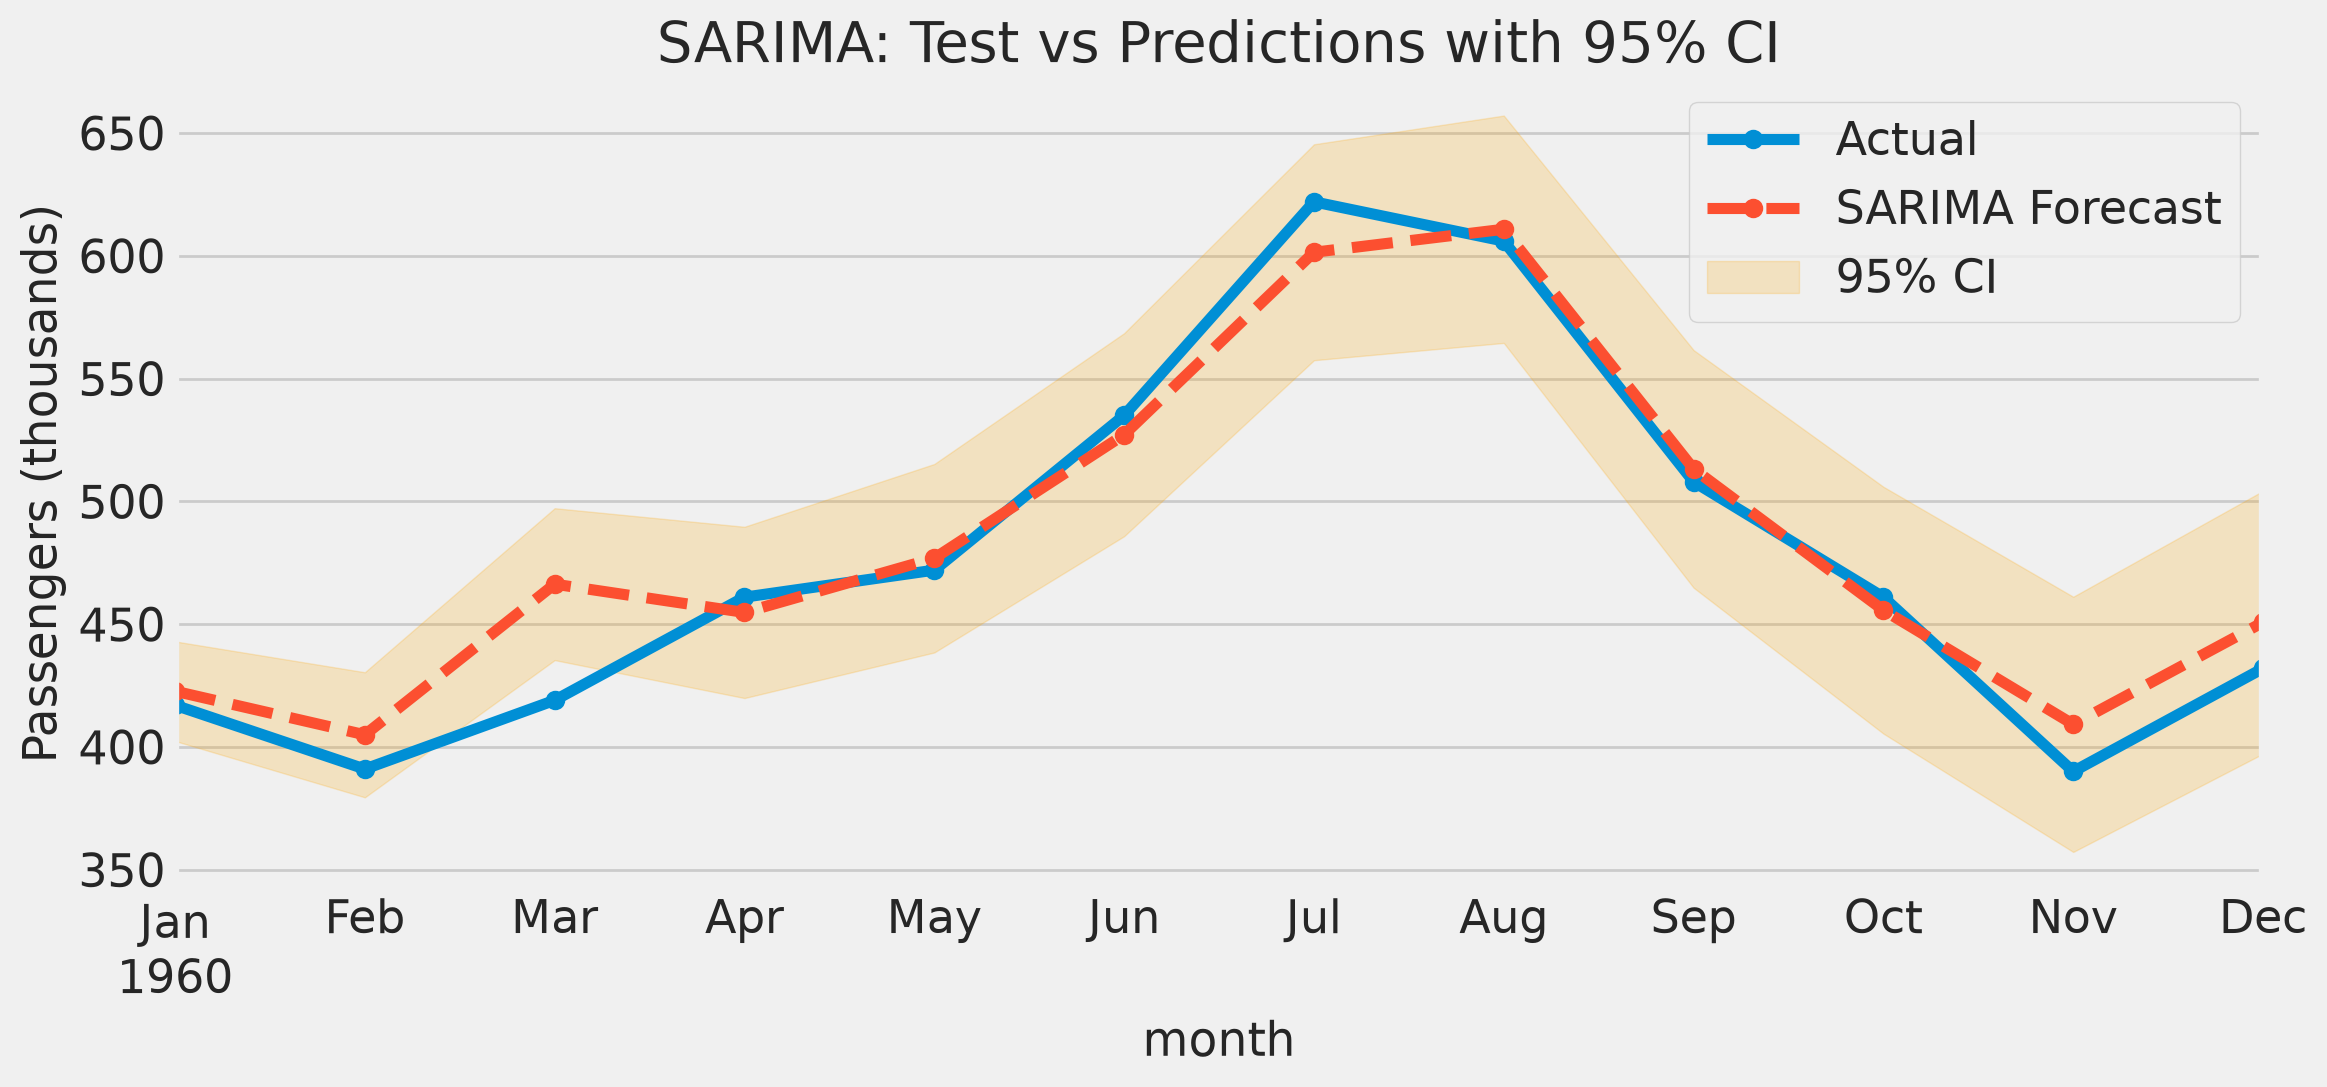

month
1960-01-01    422.703384
1960-02-01    404.947174
1960-03-01    466.293253
1960-04-01    454.781290
1960-05-01    476.848621
1960-06-01    527.162818
1960-07-01    601.449801
1960-08-01    610.821682
1960-09-01    513.229978
1960-10-01    455.692608
1960-11-01    409.200036
1960-12-01    450.754149
Freq: MS, Name: predicted_mean, dtype: float64

In [21]:
#YOUR CODE HERE
sarima_forecast = sarima_fit.get_forecast(steps=12)
sarima_pred = sarima_forecast.predicted_mean
sarima_pred.index = df_test.index
sarima_ci = sarima_forecast.conf_int(alpha=0.05)
sarima_ci.index = df_test.index

fig, ax = plt.subplots(figsize=(12, 5))
df_test['thousands_of_passengers'].plot(ax=ax, label='Actual', marker='o')
sarima_pred.plot(ax=ax, label='SARIMA Forecast', marker='o', linestyle='--')
ax.fill_between(df_test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.2, color='orange', label='95% CI')
ax.set_title('SARIMA: Test vs Predictions with 95% CI')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.show()

sarima_pred


### B5. Evaluate

In [22]:
# Compute RMSE
sarima_rmse = rmse(df_test['thousands_of_passengers'], sarima_pred)
print(f"SARIMA RMSE: {sarima_rmse:.2f}")
print(f"Test mean: {df_test['thousands_of_passengers'].mean():.2f}")
print(f"RMSE as % of mean: {sarima_rmse / df_test['thousands_of_passengers'].mean() * 100:.1f}%")


SARIMA RMSE: 17.82
Test mean: 476.17
RMSE as % of mean: 3.7%


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

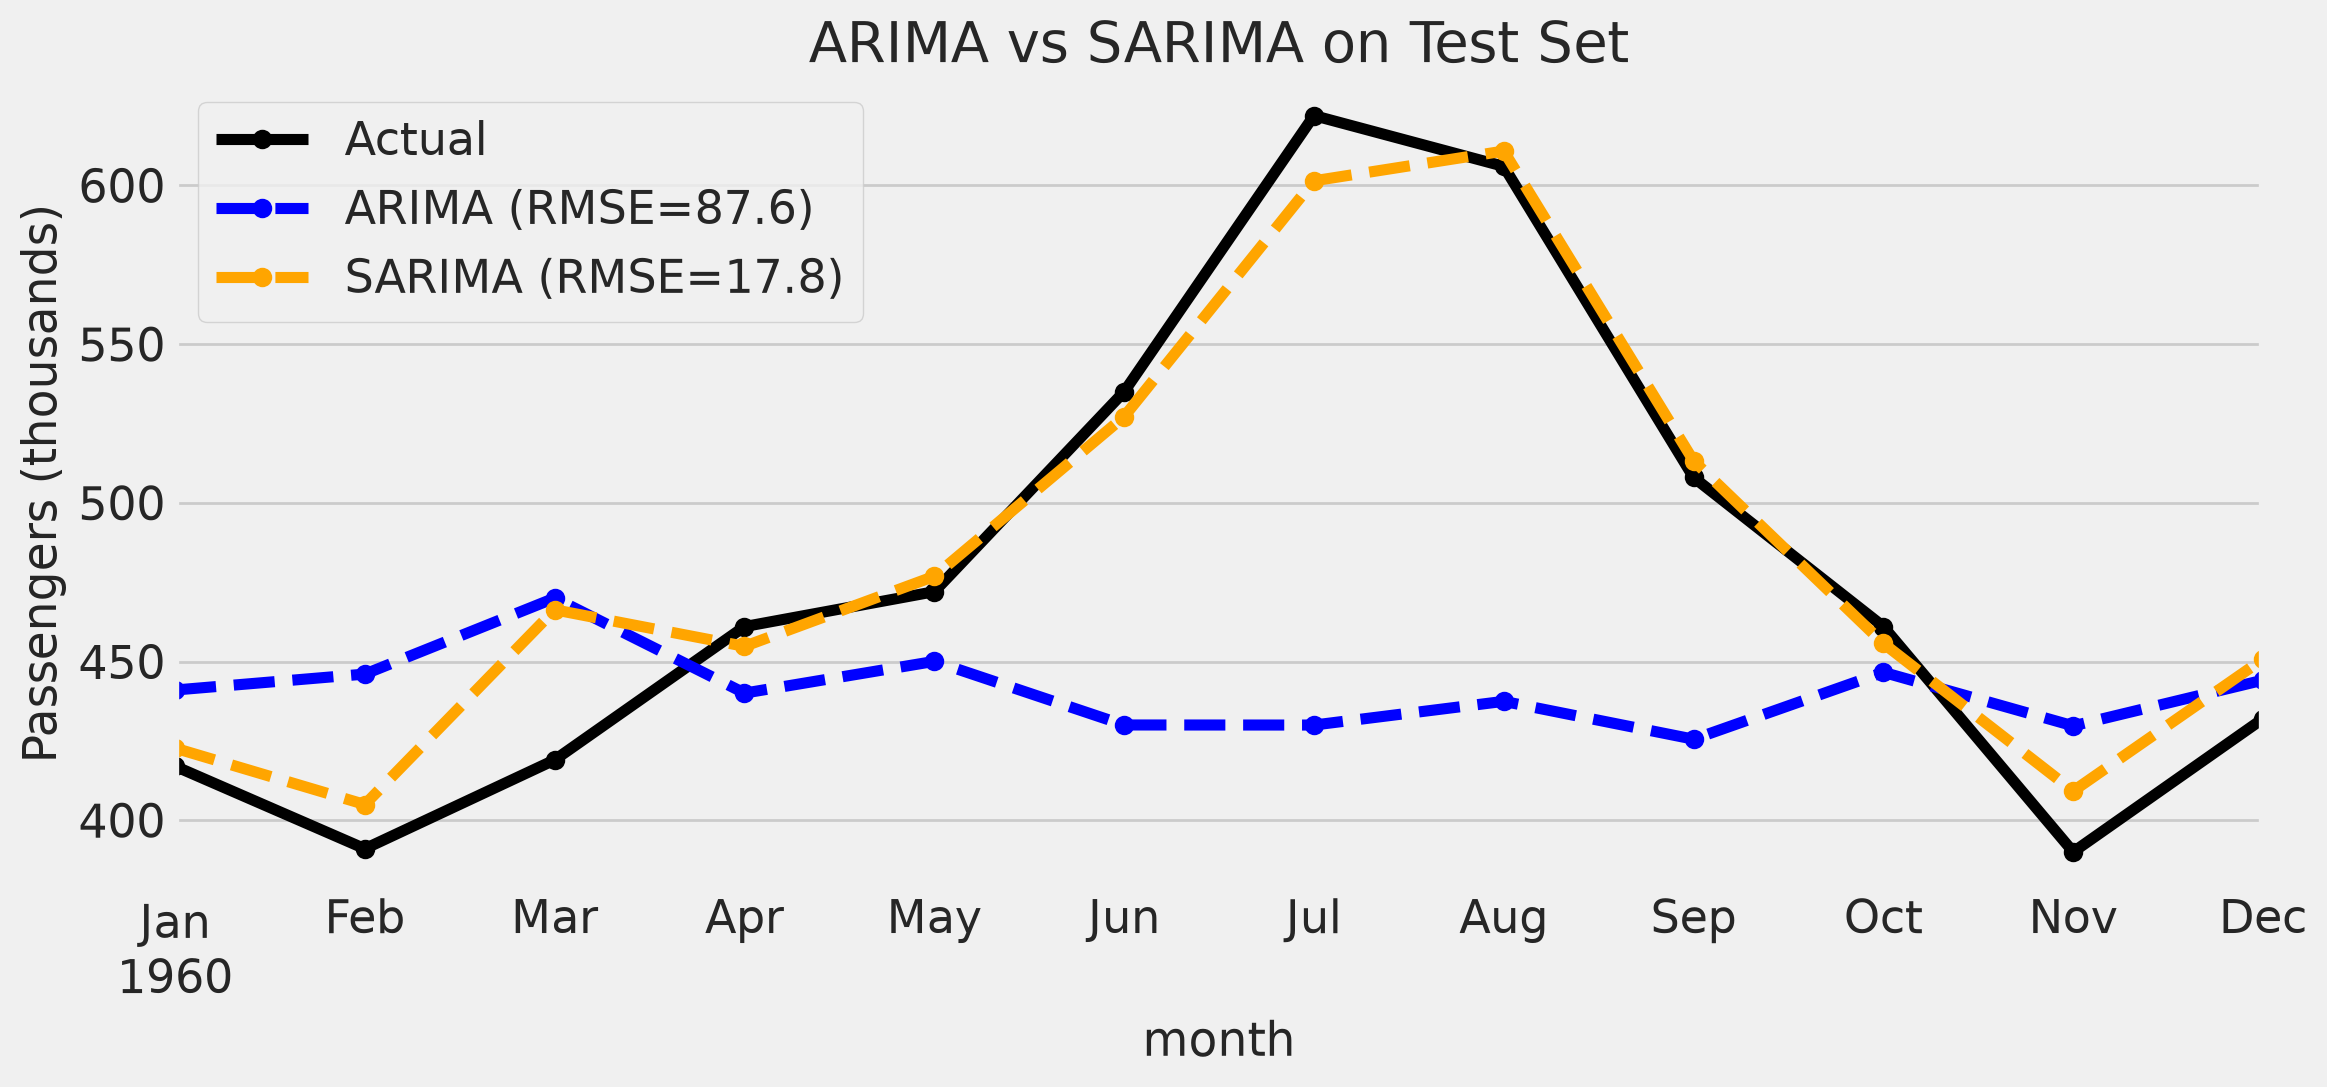

ARIMA RMSE:  87.64
SARIMA RMSE: 17.82
Improvement: 79.7%


In [23]:
#YOUR CODE HERE
fig, ax = plt.subplots(figsize=(12, 5))
df_test['thousands_of_passengers'].plot(ax=ax, label='Actual', marker='o', color='black')
arima_pred.plot(ax=ax, label=f'ARIMA (RMSE={arima_rmse:.1f})', marker='o', linestyle='--', color='blue')
sarima_pred.plot(ax=ax, label=f'SARIMA (RMSE={sarima_rmse:.1f})', marker='o', linestyle='--', color='orange')
ax.set_title('ARIMA vs SARIMA on Test Set')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.show()

print(f"ARIMA RMSE:  {arima_rmse:.2f}")
print(f"SARIMA RMSE: {sarima_rmse:.2f}")
print(f"Improvement: {(arima_rmse - sarima_rmse) / arima_rmse * 100:.1f}%")


<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

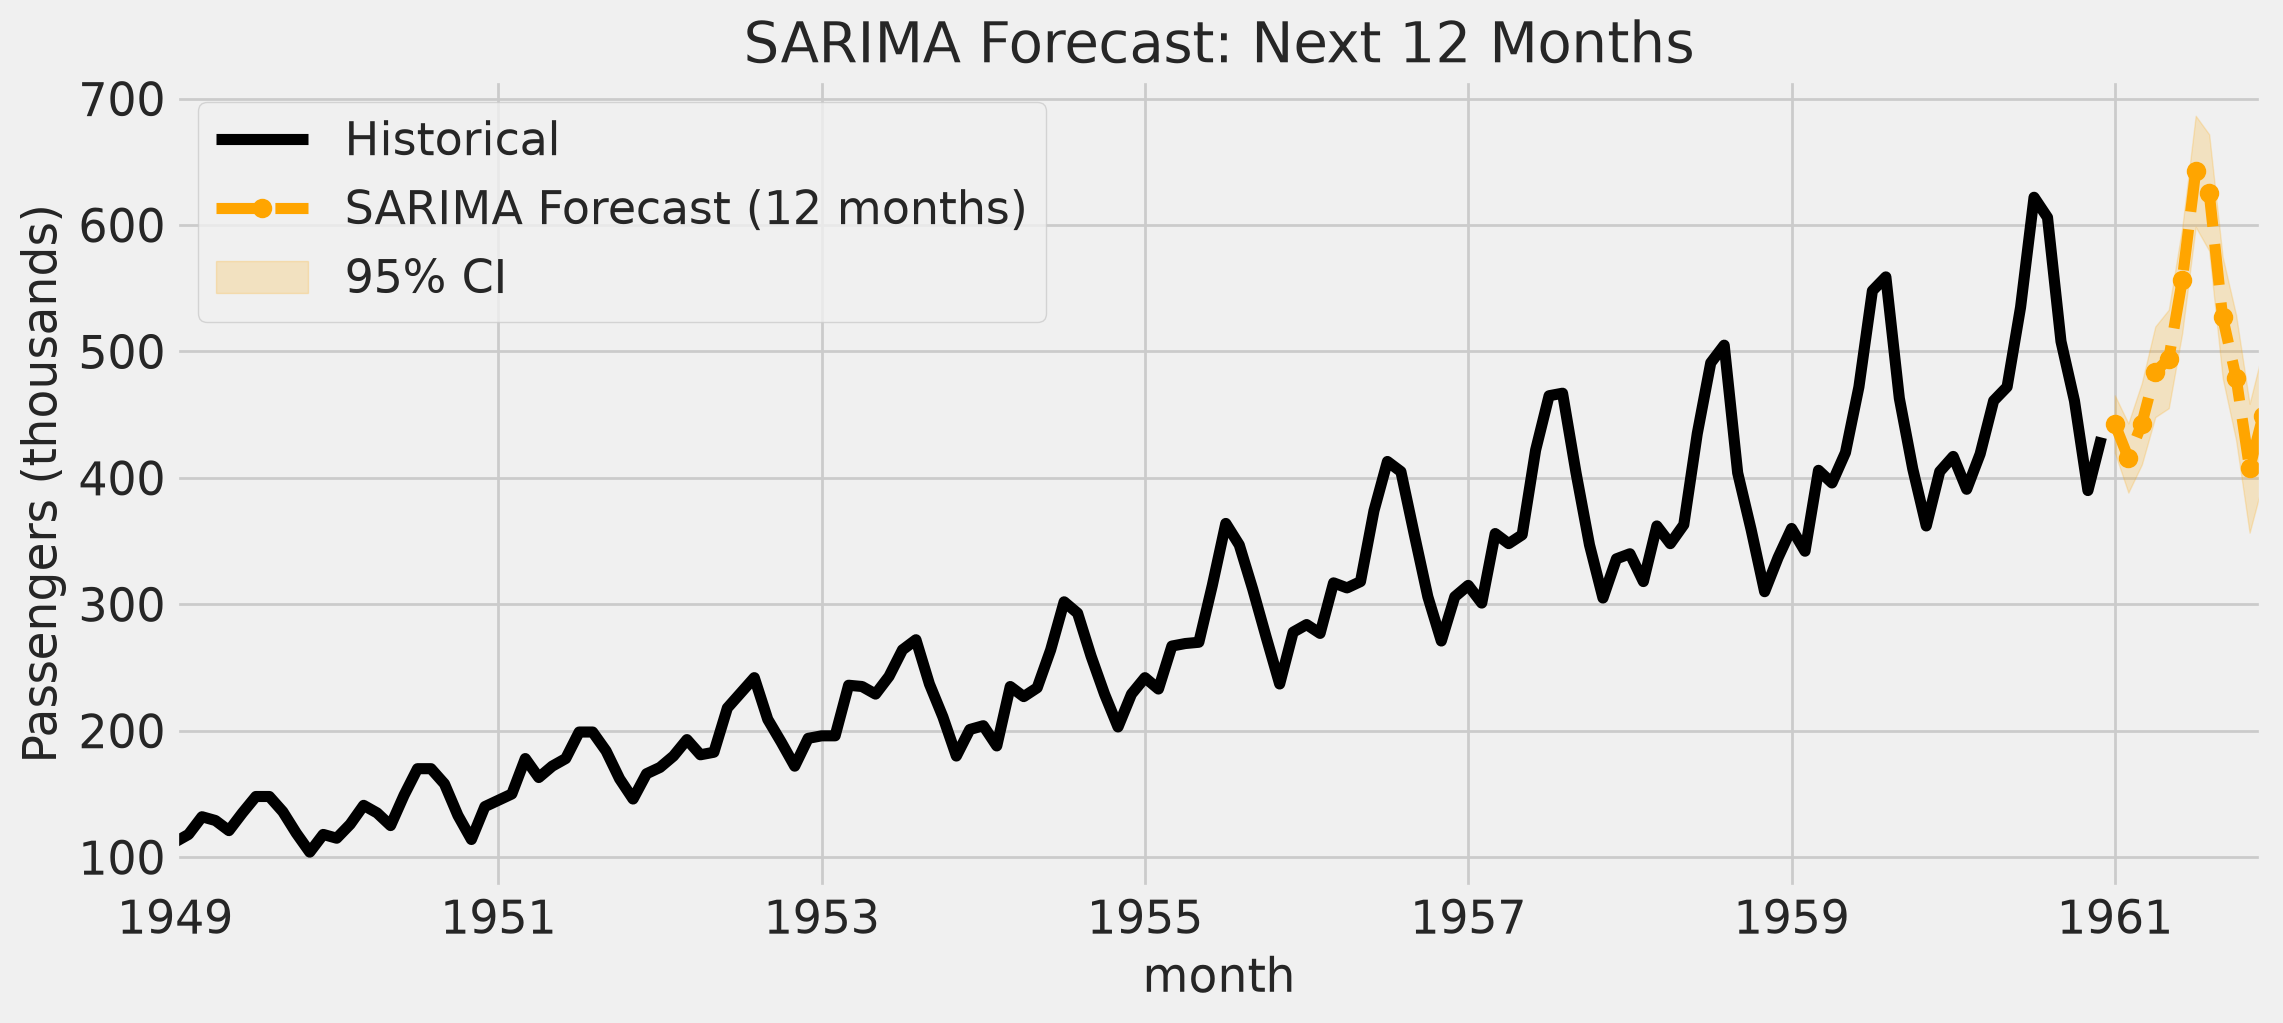

Forecast values:
1961-01-01    442.572262
1961-02-01    415.759408
1961-03-01    442.804703
1961-04-01    483.945000
1961-05-01    494.096430
1961-06-01    556.286062
1961-07-01    642.503077
1961-08-01    625.749694
1961-09-01    527.023719
1961-10-01    479.324525
1961-11-01    407.650996
1961-12-01    449.002234
Freq: MS, Name: predicted_mean, dtype: float64


In [24]:
#YOUR CODE HERE
# SARIMA wins, retrain on full dataset
sarima_final = SARIMAX(df['thousands_of_passengers'], order=order, seasonal_order=seasonal_order)
sarima_final_fit = sarima_final.fit(disp=False)

# Forecast 12 months into the future
forecast = sarima_final_fit.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

# Create future dates
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
forecast_mean.index = future_dates
forecast_ci.index = future_dates

# Plot with confidence intervals
fig, ax = plt.subplots(figsize=(12, 5))
df['thousands_of_passengers'].plot(ax=ax, label='Historical', color='black')
forecast_mean.plot(ax=ax, label='SARIMA Forecast (12 months)', marker='o', linestyle='--', color='orange')
ax.fill_between(future_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], alpha=0.2, color='orange', label='95% CI')
ax.set_title('SARIMA Forecast: Next 12 Months')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.show()

print("Forecast values:")
print(forecast_mean)


## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
